In [1]:
from google.colab import drive
drive.mount('/content/drive')

embedding_dir = "/content/drive/MyDrive/embeddings"

Mounted at /content/drive


# Load Embeddings
- dataset:
    - positive training data
    - negative training data
    - positive test data
    - negative test data

In [2]:
import numpy as np
import os

pos_train = np.load(os.path.join(embedding_dir, "positive_train.npy"))
neg_train = np.load(os.path.join(embedding_dir, "negative_train.npy"))
pos_test = np.load(os.path.join(embedding_dir, "positive_test.npy"))
neg_test = np.load(os.path.join(embedding_dir, "negative_test.npy"))

y_pos_train = np.ones(len(pos_train), dtype=int)
y_neg_train = np.zeros(len(neg_train), dtype=int)

y_pos_test = np.ones(len(pos_test), dtype=int)
y_neg_test = np.zeros(len(neg_test), dtype=int)

X_train_all = np.concatenate([pos_train, neg_train], axis=0)
y_train_all = np.concatenate([y_pos_train, y_neg_train], axis=0)

X_test = np.concatenate([pos_test, neg_test], axis=0)
y_test = np.concatenate([y_pos_test, y_neg_test], axis=0)

print(pos_train.shape)
print(neg_train.shape)
print(pos_test.shape)
print(neg_test.shape)

(3338, 185, 320)
(3338, 185, 320)
(835, 185, 320)
(835, 185, 320)


## Split validation dataset form training dataset
- original training dataset:
    - 80% training dataset
    - 20% validation dataset

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train_all,
    y_train_all,
    test_size=0.2,
    random_state=42,
    stratify=y_train_all
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (5340, 185, 320)
X_val: (1336, 185, 320)
X_test: (1670, 185, 320)


## Sequence-level embedding
Because the task is ubiquitination site prediction, so lysine K is the center of 21-mer sequence.

In [4]:
X_train = X_train[:, 10, :]
X_val = X_val[:, 10, :]
X_test = X_test[:, 10, :]

print("X_train center K:", X_train.shape)
print("X_val center K:", X_val.shape)
print("X_test center K:", X_test.shape)

X_train center K: (5340, 320)
X_val center K: (1336, 320)
X_test center K: (1670, 320)


# Training Model & Evaluation

## Logistic Regression

In [5]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

## Random Forest

In [6]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

## SVM

In [7]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    probability=True,
    class_weight="balanced",
    random_state=42
)

svm_model.fit(X_train, y_train)

SVC(class_weight='balanced', probability=True, random_state=42)

In [8]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)

def evaluate_model(model, X, y):
    y_pred = model.predict(X)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X)[:, 1]
    else:
        y_prob = model.decision_function(X)

    results = {
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred, zero_division=0),
        "Recall": recall_score(y, y_pred, zero_division=0),
        "F1-score": f1_score(y, y_pred, zero_division=0),
        "AUROC": roc_auc_score(y, y_prob),
        "AUPRC": average_precision_score(y, y_prob),
        "Confusion Matrix": confusion_matrix(y, y_pred)
    }

    return results

## Validation evaluation

In [9]:
models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "SVM": svm_model
}

for name, model in models.items():
    result = evaluate_model(model, X_val, y_val)
    print("=====", name, "Validation Results =====")
    for k, v in result.items():
        print(k, ":", v)
    print()

===== Logistic Regression Validation Results =====
Accuracy : 0.842814371257485
Precision : 0.8669871794871795
Recall : 0.8098802395209581
F1-score : 0.8374613003095975
AUROC : 0.9242174333966797
AUPRC : 0.934479455098162
Confusion Matrix : [[585  83]
 [127 541]]

===== Random Forest Validation Results =====
Accuracy : 0.8705089820359282
Precision : 0.9159663865546218
Recall : 0.8158682634730539
F1-score : 0.8630245447347585
AUROC : 0.9394620190756212
AUPRC : 0.9492565364843027
Confusion Matrix : [[618  50]
 [123 545]]

===== SVM Validation Results =====
Accuracy : 0.8495508982035929
Precision : 0.8964346349745331
Recall : 0.7904191616766467
F1-score : 0.8400954653937948
AUROC : 0.9287263795761769
AUPRC : 0.9412778836330284
Confusion Matrix : [[607  61]
 [140 528]]



## Test evaluation

In [19]:
import pandas as pd

test_results = []

metrics_df = pd.DataFrame(test_results)
metrics_df

for name, model in models.items():
    result = evaluate_model(model, X_test, y_test)

    test_results.append({
        "Model": name,
        "Accuracy": result["Accuracy"],
        "Precision": result["Precision"],
        "Recall": result["Recall"],
        "F1-score": result["F1-score"],
        "AUROC": result["AUROC"],
        "AUPRC": result["AUPRC"]
    })

metrics_df = pd.DataFrame(test_results)
metrics_df

,Model,Accuracy,Precision,Recall,F1-score,AUROC,AUPRC
0,Logistic Regression,0.855090,0.890646,0.809581,0.848181,0.930939,0.939373
1,Random Forest,0.861677,0.917127,0.795210,0.851828,0.943205,0.950703
2,SVM,0.847305,0.909605,0.771257,0.834738,0.932663,0.943693


In [21]:
import os

os.makedirs("content/results", exist_ok=True)

metrics_df.to_csv("/content/drive/MyDrive/results/metrics.csv", index=False)

In [22]:
best_model_name = metrics_df.sort_values("F1-score", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]

print("Best model:", best_model_name)

Best model: Random Forest


## Confusion matrix

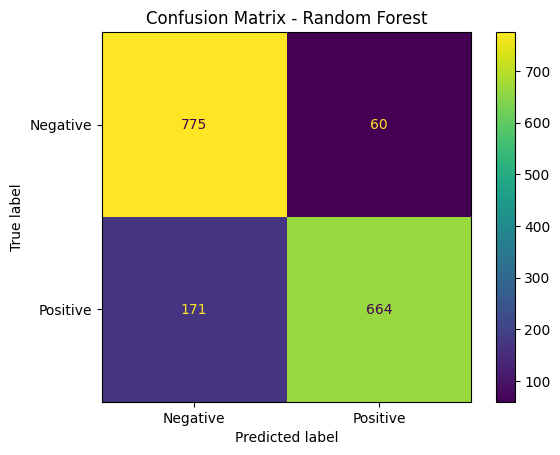

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

y_test_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title(f"Confusion Matrix - {best_model_name}")
plt.savefig("results/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()